# Імпорт бібліотек

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Кластеризація 2D датасету

# Завантаження даних

In [4]:
df_2d = pd.read_csv("data_2d.csv")

print("Перші рядки 2D датасету:")
print(df_2d.head())

X_2d = df_2d.values

Перші рядки 2D датасету:
   0.000000000000000000e+00  -7.687164597386728637e-01  \
0                       0.0                   2.687848   
1                       0.0                  -0.201379   
2                       0.0                   0.608496   
3                       0.0                  -0.082282   
4                       0.0                   2.083069   

   4.608603078297135447e-01  
0                  2.366961  
1                  0.470430  
2                  1.225400  
3                  1.137218  
4                  2.694482  


# Ліктевий метод

In [5]:
inertia_2d = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_2d)
    inertia_2d.append(kmeans.inertia_)

# Візуалізація Elbow

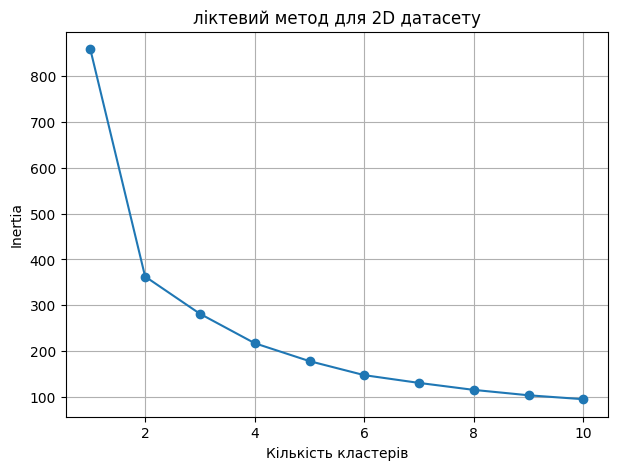

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertia_2d, marker="o")
plt.xlabel("Кількість кластерів")
plt.ylabel("Inertia")
plt.title("ліктевий метод для 2D датасету")

plt.grid()
plt.show()

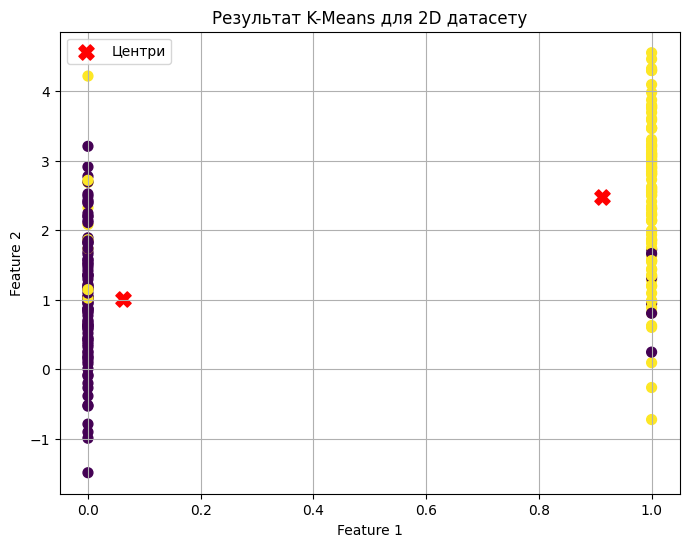

In [12]:
# K-Means з оптимальною кількістю кластерів
# Змінити відповідно до графіка Elbow

optimal_k_2d = 2
kmeans_2d = KMeans(n_clusters=optimal_k_2d, random_state=42, n_init=10)
clusters_2d = kmeans_2d.fit_predict(X_2d)

# Візуалізація кластерів 2D

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_2d, cmap="viridis", s=50)

# Центри кластерів

plt.scatter(
    kmeans_2d.cluster_centers_[:, 0],
    kmeans_2d.cluster_centers_[:, 1],
    marker="X",
    s=120,
    color="red",
    label="Центри",
)

plt.title("Результат K-Means для 2D датасету")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()
plt.show()

# Кластеризація MNIST
# Завантаження MNIST

In [13]:
mnist = pd.read_csv("mnist.csv")

print("\nПерші рядки MNIST:")
print(mnist.head())

print("\nРозмір MNIST:", mnist.shape)


Перші рядки MNIST:
   7  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.658  0.659  0.660  \
0  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  4  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.661  0.662  0.663  0.664  0.665  0.666  0.667  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]

Розмір MNIST: (499, 785)


# Видалення стовпця label

In [14]:
X_mnist = mnist.iloc[:, 1:]
print(
    "Розмірність MNIST після видалення label:",
    X_mnist.shape
)

Розмірність MNIST після видалення label: (499, 784)


# Масштабування

In [ ]:
scaler = StandardScaler()
X_mnist_scaled = scaler.fit_transform(X_mnist)

# PCA для MNIST

In [16]:
pca = PCA(n_components=2)
X_mnist_pca = pca.fit_transform(X_mnist_scaled)
print("Розмірність після PCA:", X_mnist_pca.shape)

Розмірність після PCA: (499, 2)


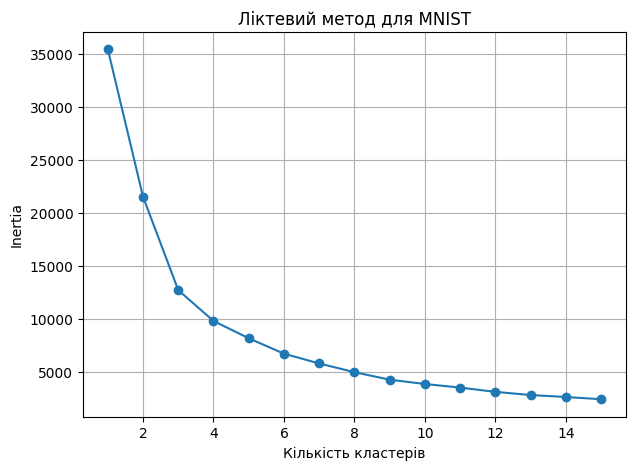

In [17]:
# Метод ліктя після PCA

inertia_mnist = []
for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_mnist_pca)
    inertia_mnist.append(kmeans.inertia_)

# Графік Elbow

plt.figure(figsize=(7, 5))
plt.plot(range(1, 16), inertia_mnist, marker="o")
plt.xlabel("Кількість кластерів")
plt.ylabel("Inertia")
plt.title("Ліктевий метод для MNIST")
plt.grid()
plt.show()

# K-Means MNIST

In [18]:
optimal_k_mnist = 3
kmeans_mnist = KMeans(n_clusters=optimal_k_mnist, random_state=42, n_init=10)
clusters_mnist = kmeans_mnist.fit_predict(X_mnist_pca)
print("\nКластери MNIST:", np.unique(clusters_mnist))


Кластери MNIST: [0 1 2]


# Візуалізація MNIST після PCA

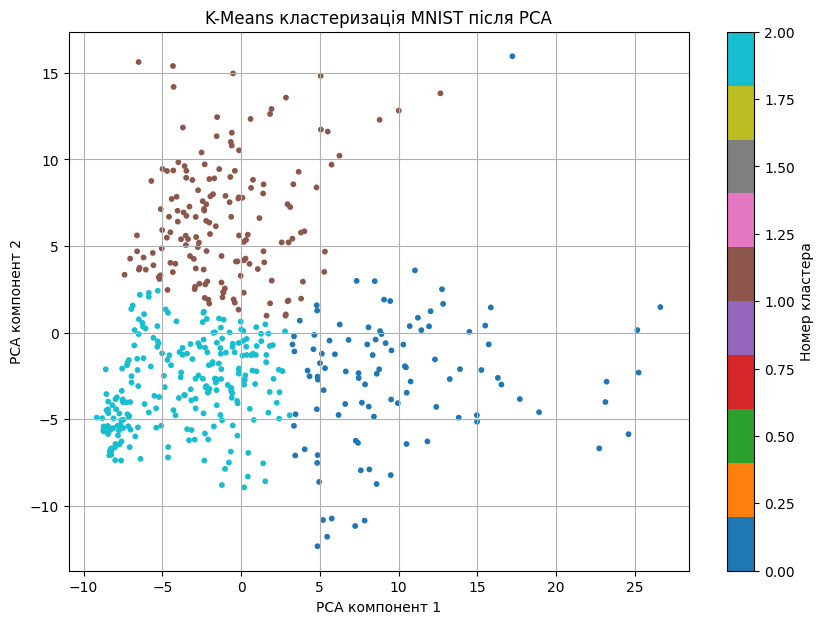

In [19]:
plt.figure(figsize=(10, 7))
plt.scatter(X_mnist_pca[:, 0], X_mnist_pca[:, 1], c=clusters_mnist, cmap="tab10", s=10)
plt.xlabel("PCA компонент 1")
plt.ylabel("PCA компонент 2")
plt.title("K-Means кластеризація MNIST після PCA")
plt.colorbar(label="Номер кластера")
plt.grid()
plt.show()